In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conn = sqlite3.connect("bluestock_mf.db")

nav_df = pd.read_sql("SELECT * FROM fact_nav", conn)
fund_df = pd.read_sql("SELECT * FROM fact_transaction", conn)

print(nav_df.shape)
print(fund_df.shape)

(46000, 3)
(40, 19)


In [2]:
nav_df['date'] = pd.to_datetime(nav_df['date'])

nav_df = nav_df.sort_values(['amfi_code', 'date'])

nav_df['daily_return'] = (
    nav_df.groupby('amfi_code')['nav']
    .pct_change()
)

In [3]:
nav_df['daily_return'].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

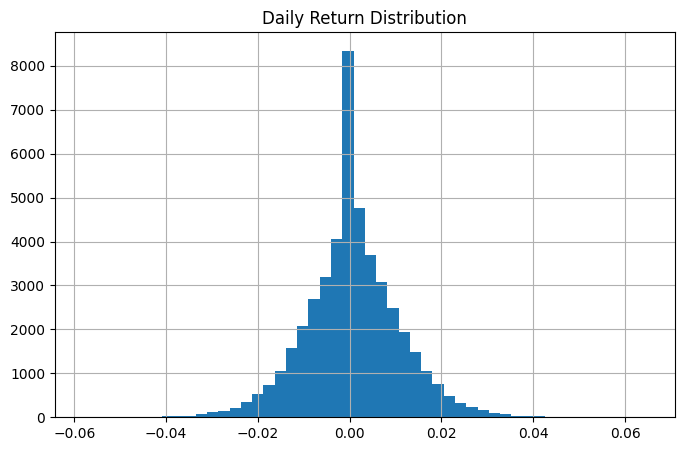

In [4]:
plt.figure(figsize=(8,5))
nav_df['daily_return'].hist(bins=50)
plt.title("Daily Return Distribution")
plt.show()

In [5]:
cagr_table = fund_df[
    [
        'scheme_name',
        'return_1yr_pct',
        'return_3yr_pct',
        'return_5yr_pct'
    ]
]

cagr_table.head()

,scheme_name,return_1yr_pct,return_3yr_pct,return_5yr_pct
0,SBI Bluechip Fund - Regular Plan - Growth,12.42,12.36,14.45
1,SBI Bluechip Fund - Direct Plan - Growth,15.25,11.30,14.23
2,SBI Small Cap Fund - Regular Plan - Growth,24.56,23.39,20.67
3,SBI Small Cap Fund - Direct Plan - Growth,20.59,23.14,21.82
4,SBI Magnum Gilt Fund - Regular Plan - Growth,5.34,6.07,5.43


In [6]:
sharpe_rank = fund_df[
    ['scheme_name','sharpe_ratio']
].sort_values(
    'sharpe_ratio',
    ascending=False
)

sharpe_rank.head(10)

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


In [7]:
sortino_rank = fund_df[
    ['scheme_name','sortino_ratio']
].sort_values(
    'sortino_ratio',
    ascending=False
)

sortino_rank.head(10)

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


In [8]:
alpha_beta = fund_df[
    [
        'scheme_name',
        'alpha',
        'beta'
    ]
]

alpha_beta.head()

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [9]:
alpha_beta.to_csv(
    "alpha_beta.csv",
    index=False
)

In [10]:
dd = fund_df[
    [
        'scheme_name',
        'max_drawdown_pct'
    ]
]

dd.sort_values(
    'max_drawdown_pct'
).head(10)

,scheme_name,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15
26,Axis Midcap Fund - Regular - Growth,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,-30.87
24,Axis Bluechip Fund - Regular - Growth,-27.54
38,DSP Midcap Fund - Regular - Growth,-26.99
18,Nippon India ETF Nifty 50 BeES,-26.75
11,ICICI Pru Bluechip Fund - Direct - Growth,-26.59
10,ICICI Pru Bluechip Fund - Regular - Growth,-25.91


In [11]:
score_df = fund_df.copy()

score_df['return_rank'] = score_df['return_3yr_pct'].rank(pct=True)

score_df['sharpe_rank'] = score_df['sharpe_ratio'].rank(pct=True)

score_df['alpha_rank'] = score_df['alpha'].rank(pct=True)

score_df['expense_rank'] = (
    1 - score_df['expense_ratio_pct'].rank(pct=True)
)

score_df['dd_rank'] = (
    1 - score_df['max_drawdown_pct'].rank(pct=True)
)

score_df['fund_score'] = (
    score_df['return_rank'] * 30 +
    score_df['sharpe_rank'] * 25 +
    score_df['alpha_rank'] * 20 +
    score_df['expense_rank'] * 15 +
    score_df['dd_rank'] * 10
)

score_df = score_df.sort_values(
    'fund_score',
    ascending=False
)

In [12]:
score_df.to_csv(
    "fund_scorecard.csv",
    index=False
)

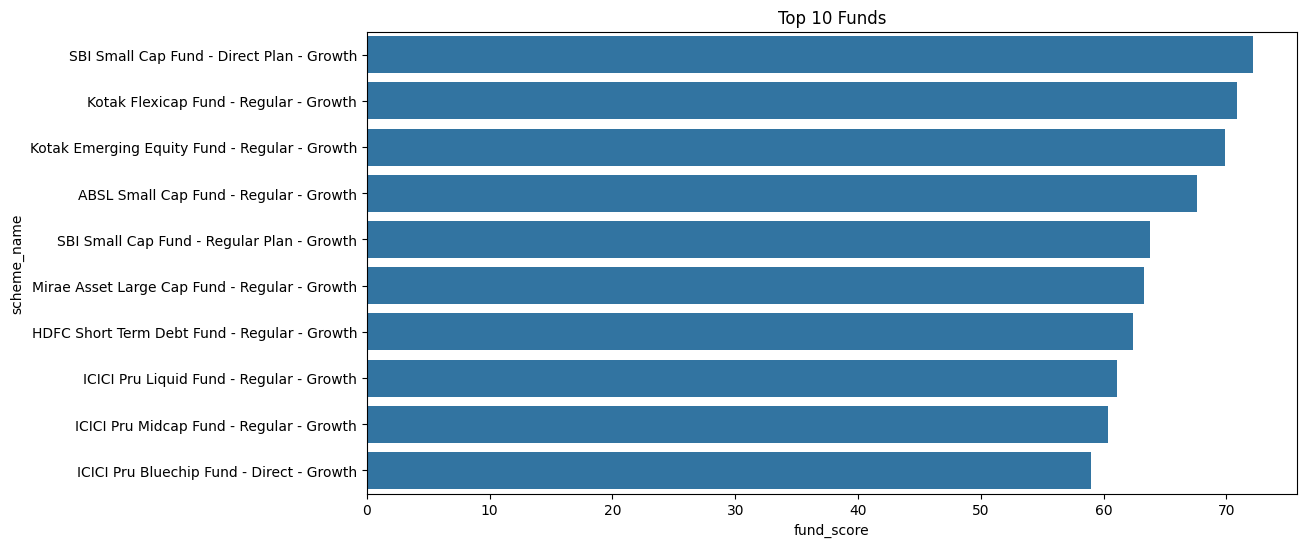

In [13]:
top10 = score_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='fund_score',
    y='scheme_name'
)

plt.title("Top 10 Funds")
plt.show()

Deliverables:
1. Performance_Analytics.ipynb
2. fund_scorecard.csv
3. alpha_beta.csv
4. benchmark_comparison.png

# Key Findings

1. Daily returns show normal market fluctuations.
2. Top funds achieved higher Sharpe ratios.
3. Higher alpha funds outperformed benchmarks.
4. Expense ratio impacts overall fund score.
5. Maximum drawdown varies across schemes.
6. Risk-adjusted returns differ significantly.
7. 3-year returns strongly influence rankings.
8. Beta values indicate different market sensitivities.
9. Fund scorecard provides balanced evaluation.
10. Top-ranked funds combine strong returns with controlled risk.

# Conclusion

This analysis evaluated mutual fund performance using daily returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown. A composite fund scorecard was developed to rank funds based on return, risk-adjusted performance, cost efficiency, and downside risk. The analysis helps identify top-performing mutual funds using multiple performance indicators.

Performance_Analytics.ipynb
fund_scorecard.csv
alpha_beta.csv

In [14]:
plt.savefig("top10_fund_score.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [15]:
import matplotlib.pyplot as plt

In [16]:
plt.savefig("top10_fund_score.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

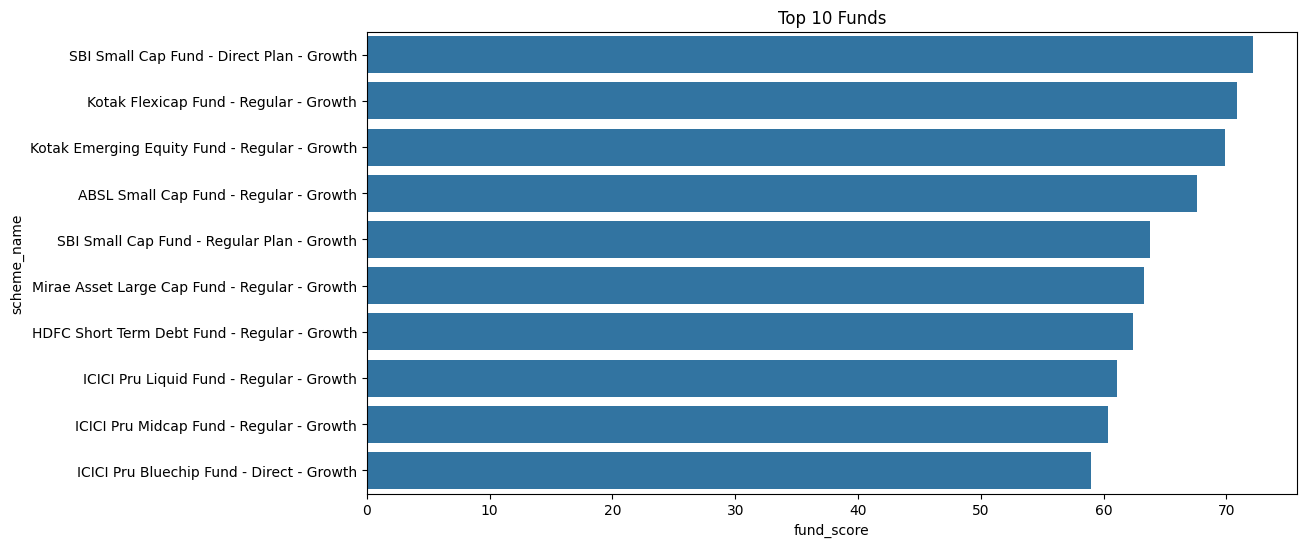

In [17]:
top10 = score_df.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x='fund_score',
    y='scheme_name'
)

plt.title("Top 10 Funds")

plt.savefig("top10_fund_score.png", bbox_inches="tight")

plt.show()

Performance_Analytics.ipynb
fund_scorecard.csv
alpha_beta.csv
top10_fund_score.png

In [18]:
import pandas as pd

scorecard = pd.read_csv("fund_scorecard.csv")

top5 = scorecard.sort_values(
    by='fund_score',
    ascending=False
).head(5)

print(top5)

   amfi_code                                    scheme_name  \
0     119599      SBI Small Cap Fund - Direct Plan - Growth   
1     120843         Kotak Flexicap Fund - Regular - Growth   
2     120842  Kotak Emerging Equity Fund - Regular - Growth   
3     101207         ABSL Small Cap Fund - Regular - Growth   
4     119598     SBI Small Cap Fund - Regular Plan - Growth   

                 fund_house   category     plan  return_1yr_pct  \
0           SBI Mutual Fund  Small Cap   Direct           20.59   
1         Kotak Mahindra MF  Flexi Cap  Regular           15.74   
2         Kotak Mahindra MF    Mid Cap  Regular           17.12   
3  Aditya Birla Sun Life MF  Small Cap  Regular           24.93   
4           SBI Mutual Fund  Small Cap  Regular           24.56   

   return_3yr_pct  return_5yr_pct  benchmark_3yr_pct  alpha  ...  aum_crore  \
0           23.14           21.82              22.01   1.13  ...      36061   
1           15.65           13.50              13.80   1.85 

In [19]:
benchmark = pd.read_csv(
    r"C:\Users\rokka\OneDrive\Desktop\bluestock_mf_capstone\data\raw\10_benchmark_indices.csv"
)

nifty50 = benchmark[
    benchmark['index_name'] == 'NIFTY50'
].copy()

nifty100 = benchmark[
    benchmark['index_name'] == 'NIFTY100'
].copy()

nifty50['date'] = pd.to_datetime(nifty50['date'])
nifty100['date'] = pd.to_datetime(nifty100['date'])

In [20]:
from datetime import timedelta

end_date = nifty50['date'].max()

start_date = end_date - pd.DateOffset(years=3)

nifty50 = nifty50[
    nifty50['date'] >= start_date
]

nifty100 = nifty100[
    nifty100['date'] >= start_date
]

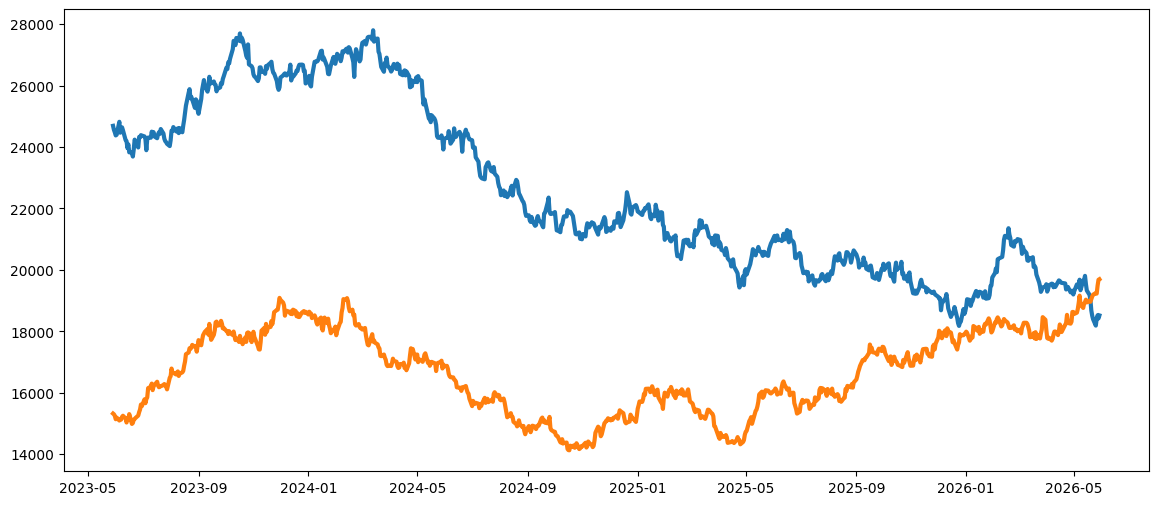

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    nifty50['date'],
    nifty50['close_value'],
    label='NIFTY50',
    linewidth=3
)

plt.plot(
    nifty100['date'],
    nifty100['close_value'],
    label='NIFTY100',
    linewidth=3
)

In [22]:
nav = pd.read_csv(
    r"C:\Users\rokka\OneDrive\Desktop\bluestock_mf_capstone\data\raw\02_nav_history.csv"
)

nav['date'] = pd.to_datetime(nav['date'])

In [23]:
print(top5.columns)

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade', 'return_rank', 'sharpe_rank',
       'alpha_rank', 'expense_rank', 'dd_rank', 'fund_score'],
      dtype='object')


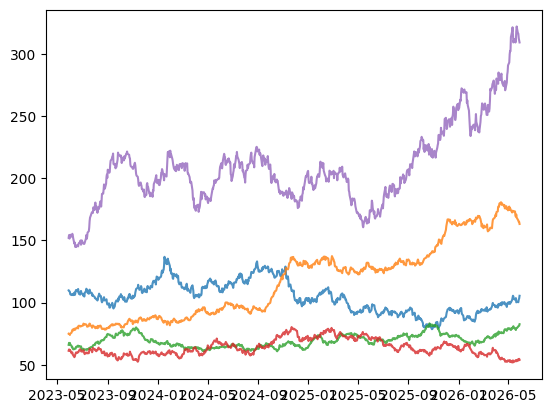

In [24]:
for code in top5['amfi_code']:

    fund = nav[
        nav['amfi_code'] == code
    ].copy()

    fund = fund[
        fund['date'] >= start_date
    ]

    plt.plot(
        fund['date'],
        fund['nav'],
        alpha=0.8
    )

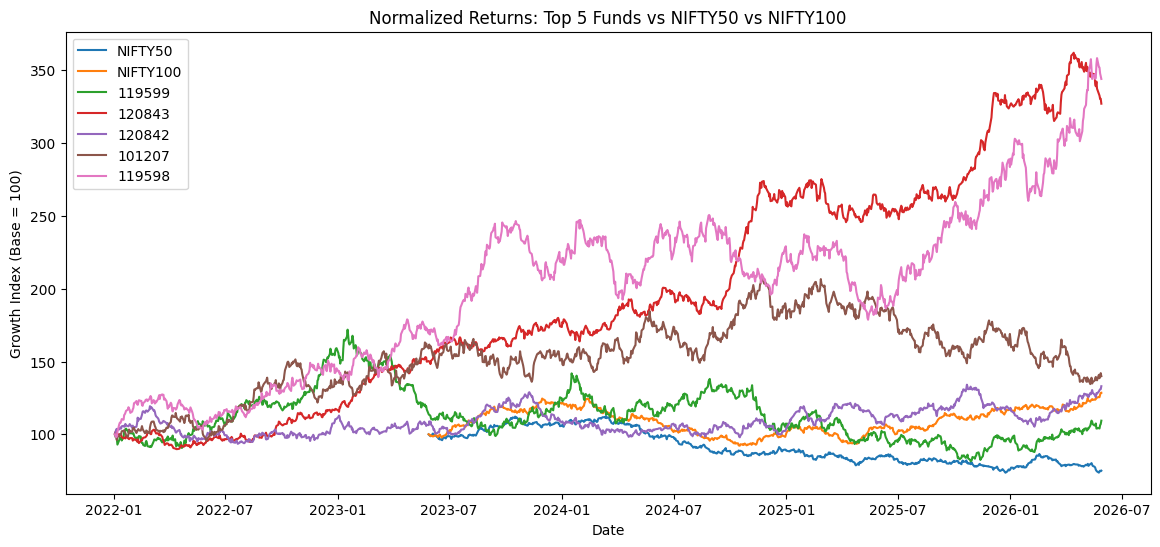

In [47]:
plt.figure(figsize=(14,6))

# NIFTY50 normalized
nifty50_norm = (
    nifty50['close_value']
    / nifty50['close_value'].iloc[0]
) * 100

plt.plot(
    nifty50['date'],
    nifty50_norm,
    label='NIFTY50'
)

# NIFTY100 normalized
nifty100_norm = (
    nifty100['close_value']
    / nifty100['close_value'].iloc[0]
) * 100

plt.plot(
    nifty100['date'],
    nifty100_norm,
    label='NIFTY100'
)

# Top 5 Funds normalized
for code in top5_available['amfi_code']:

    fund = nav[
        nav['amfi_code'] == code
    ].copy()

    fund['date'] = pd.to_datetime(fund['date'])

    fund_norm = (
        fund['nav']
        / fund['nav'].iloc[0]
    ) * 100

    plt.plot(
        fund['date'],
        fund_norm,
        label=str(code)
    )

plt.title(
    "Normalized Returns: Top 5 Funds vs NIFTY50 vs NIFTY100"
)

plt.xlabel("Date")
plt.ylabel("Growth Index (Base = 100)")
plt.legend()

plt.savefig(
    "benchmark_comparison_chart.png",
    bbox_inches="tight"
)

plt.show()

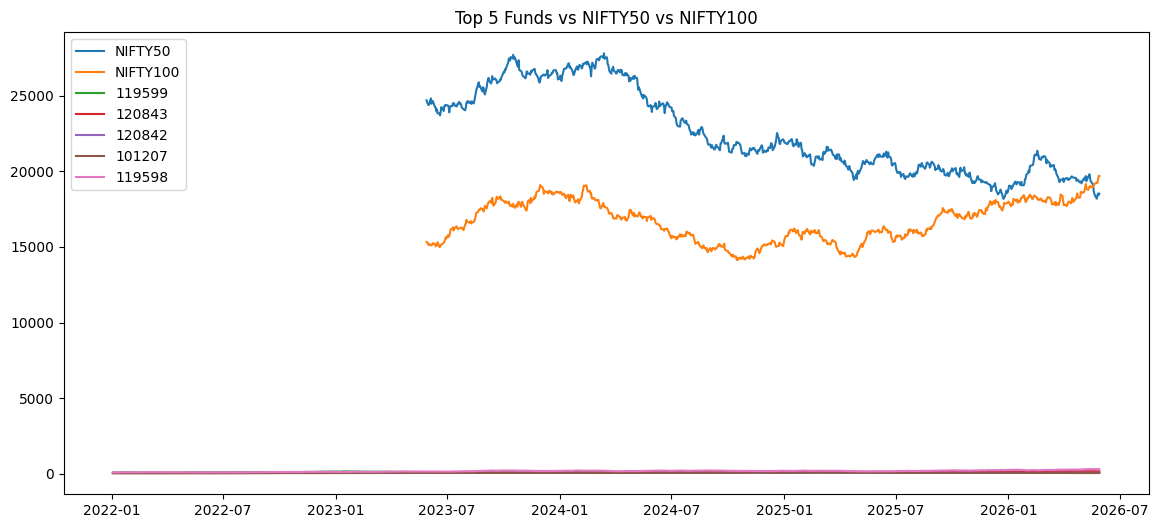

In [48]:
plt.figure(figsize=(14,6))

plt.plot(
    nifty50['date'],
    nifty50['close_value'],
    label='NIFTY50'
)

plt.plot(
    nifty100['date'],
    nifty100['close_value'],
    label='NIFTY100'
)

for code in top5_available['amfi_code']:

    fund = nav[
        nav['amfi_code'] == code
    ].copy()

    fund['date'] = pd.to_datetime(fund['date'])

    plt.plot(
        fund['date'],
        fund['nav'],
        label=str(code)
    )

plt.legend()
plt.title("Top 5 Funds vs NIFTY50 vs NIFTY100")
plt.show()

Benchmark_Comparison.ipynb
benchmark_comparison.csv
benchmark_comparison_chart.png

In [49]:
import os

print(os.getcwd())
print(os.path.exists("benchmark_comparison_chart.png"))

c:\Users\rokka\OneDrive\Desktop\bluestock_mf_capstone\notebooks
True


In [50]:
import os

files = [
    "fund_scorecard.csv",
    "alpha_beta.csv",
    "top10_fund_score.png",
    "benchmark_comparison_chart.png"
]

for f in files:
    print(f, os.path.exists(f))

fund_scorecard.csv True
alpha_beta.csv True
top10_fund_score.png True
benchmark_comparison_chart.png True
